Convolutional Neural Networks
============


Overview
-------------
Neural Networks receive an input (a single vector), and transform it through a series of hidden layers. Each hidden layer is made up of a set of neurons, where each neuron is fully connected to all neurons in the previous layer, and where neurons in a single layer function completely independently and do not share any connections. The last fully-connected layer is called the “output layer” and in classification settings it represents the class scores.

<u>Regular Neural Nets don’t scale well to full images.</u> For images of size 200x200x3, a single fully-connected neuron in a first hidden layer of a regular Neural Network would have 200*200*3 = 120,000 weights. Moreover, we would almost certainly want to have several such neurons, so the parameters would add up quickly. <u>Clearly, this full connectivity is wasteful and the huge number of parameters would quickly lead to overfitting.</u>

3D volumes of neurons. Convolutional Neural Networks take advantage of the fact that the input consists of images and they constrain the architecture in a more sensible way. In particular, unlike a regular Neural Network, the layers of a ConvNet have neurons arranged in 3 dimensions: width, height, depth. <u>The neurons in a layer will only be connected to a small region of the layer before it, instead of all of the neurons in a fully-connected manner.</u>

---

| Regular NN | ConvNet |
| :-: | :-: |
| <img src="https://cs231n.github.io/assets/nn1/neural_net2.jpeg" width="300" height="180"> | <img src="https://cs231n.github.io/assets/cnn/cnn.jpeg" width="300" height="180"> |

<small>Left: A regular 3-layer Neural Network. Right: A ConvNet arranges its neurons in three dimensions (width, height, depth), as visualized in one of the layers. Every layer of a ConvNet transforms the 3D input volume to a 3D output volume of neuron activations. In this example, the red input layer holds the image, so its width and height would be the dimensions of the image, and the depth would be 3 (Red, Green, Blue channels).</small>

---

Layers used to build ConvNets
---------------

We use three main types of layers to build ConvNet architectures: <u>Convolutional Layer, Pooling Layer, and Fully-Connected Layer.</u>

*Example Architecture*: A simple ConvNet for CIFAR-10 classification could have the architecture [INPUT - CONV - RELU - POOL - FC]. In more detail:

<div style="font-size: 95%;">

- **INPUT** [32x32x3] will hold the raw pixel values of the image, in this case an image of width 32, height 32, and with three color channels R,G,B.

- **CONV layer** will compute the output of neurons that are connected to <u>local regions in the input</u>, each computing a dot product between their weights and a small region they are connected to in the input volume. This may result in volume such as [32x32x12] if we decided to use 12 <u>*filters*</u>.

- **RELU layer** will apply an elementwise activation function, such as the max(0,x) thresholding at zero. This leaves the size of the volume unchanged ([32x32x12]).

- **POOL layer** will perform a <u>downsampling</u> operation along the spatial dimensions (width, height), resulting in volume such as [16x16x12].

- **FC (i.e. fully-connected) layer** will compute the class scores, resulting in volume of size [1x1x10], where each of the 10 numbers correspond to a class score, such as among the 10 categories of CIFAR-10. As with ordinary Neural Networks and as the name implies, each neuron in this layer will be connected to all the numbers in the previous volume.

</div>


Convolutional Layer
------------------

The CONV layer’s parameters consist of a set of learnable filters. Every filter is small spatially, but extends through the full depth of the input volume. uring the forward pass, we slide (more precisely, convolve) each filter across the width and height of the input volume and compute dot products between the entries of the filter and the input at any position. As we slide the filter over the width and height of the input volume we will produce a 2-dimensional activation map that gives the responses of that filter at every spatial position. Intuitively, the network will learn filters that activate when they see some type of visual feature such as an edge of some orientation or a blotch of some color on the first layer, or eventually entire honeycomb or wheel-like patterns on higher layers of the network.

**Spatial arrangement.** We haven’t yet discussed how many neurons there are in the output volume or how they are arranged. Three hyperparameters control the size of the output volume: the depth, stride and zero-padding.

<div style="font-size:95%;">

1. The **depth** of the output volume is a hyperparameter. It corresponds to the <u>number of filters</u> we would like to use, each learning to look for something different in the input.

2. We must specify the **stride** with which we slide the filter. When the stride is 1, we move the filters one pixel at a time.

3. Sometimes it will be convenient to pad the input volume with zeros around the border. The size of this **zero-padding** is a hyperparameter. The nice feature of zero padding is that it will allow us to <u>control the spatial size of the ouput volumes.</u> In general, we set zero-padding to be $P = (F-1)/2$ when the stride is $S=1$. This ensures that the input volume and output volume will have the same size spatially.

</div>

**The spatial size of output volume**: **$(W-F+2P)/S + 1$**, where $W$: input size, $F$: filter size, $S$: stride, $P$: amount of zerro-padding.

**Parameter Sharing**: It turns out that we can dramatically reduce the number of parameters by making one reasonable assumption: That if one feature is useful to compute at some spatial position (x,y), then it should also be useful to compute at a different position (x2,y2). In other words, denoting a single 2-dimensional slice of depth as a depth slice, we are going to constrain the neurons in each depth slice to use the same weights and bias.


Pooling Layer
-----------

It is common to periodically insert a Pooling layer in-between successive Conv layers in a ConvNet architecture. Its function is to progressively reduce the spatial size of the representation to reduce the amount of parameters and computation in the network, and hence to also control overfitting. The Pooling Layer operates independently on every depth slice of the input and resizes it spatially, using the MAX operation.

**The spatial size of output volume**:
- $W2 = (W1-F)/S + 1$
- $H2 = (H1-F)/S + 1$
- $D2 = D1$

---

![Pooling Layer](https://cs231n.github.io/assets/cnn/maxpool.jpeg)

<small>Pooling layer downsamples the volume spatially, independently in each depth slice of the input volume. The most common downsampling operation is max, giving rise to max pooling, here shown with a stride of 2. That is, each max is taken over 4 numbers (little 2x2 square).</small>

---

## 0. Library

In [36]:
import numpy as np
from scipy.signal import correlate2d
import matplotlib.pyplot as plt
import torchvision

## 1. MNIST Data

In [22]:
train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    download=True
)

print(train_dataset.data.shape)
print(train_dataset.targets.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.89MB/s]

torch.Size([60000, 28, 28])
torch.Size([60000])


## 2. Transform to Numpy Array and Normalize

In [27]:
images = []
labels = []

for i in range(1000):
    img, lbl = train_dataset[i]
    images.append(np.array(img))
    labels.append(lbl)

X = np.stack(images)
y = np.array(labels)

X = X.astype(np.float32) / 255.0

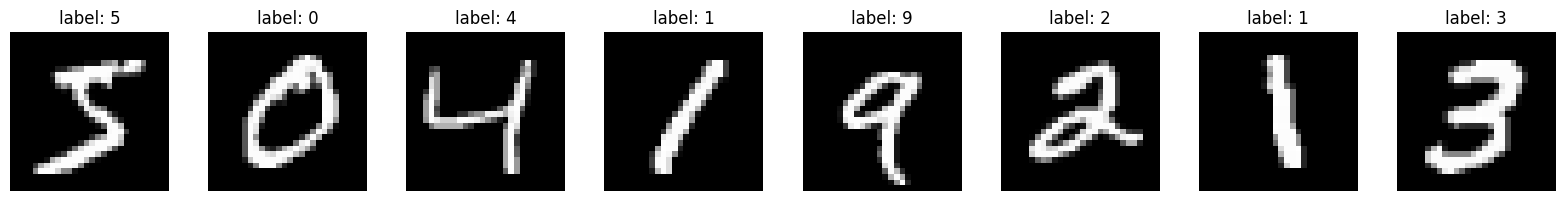

In [29]:
n = 8
fig, axes = plt.subplots(1, n, figsize=(2*n, 2))

for i in range(n):
    axes[i].imshow(X[i], cmap='gray')
    axes[i].set_title(f"label: {y[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Conv Layer Forward Pass (Single Filter)

In [87]:
def conv2d_single(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(kernel * patch)

    return output

In [88]:
np.random.seed(42)
test_image = np.random.rand(28, 28)
test_kernel = np.random.randn(3, 3)


# compare conv2d_single to correlate2d from scipy
my_result = conv2d_single(test_image, test_kernel)
scipy_result = correlate2d(test_image, test_kernel, mode='valid')
max_diff = np.max(np.abs(my_result - scipy_result))


print(f"conv2d_single Shape: {my_result.shape}")
print(f"scipy correlate2d Shape: {scipy_result.shape}")
print(f"Maximum Difference: {max_diff:.10e}")

conv2d_single Shape: (26, 26)
scipy correlate2d Shape: (26, 26)
Maximum Difference: 4.4408920985e-16


## 4. Multi-filter Expansion and Activation

In [ ]:
class ConvLayer:
    def __init__(self, num_filters=8, kernel_size=(3, 3)):
        self.num_filters = num_filters
        self.k_h, self.k_w = kernel_size

        self.filters = np.random.randn(self.num_filters, self.k_h, self.k_w) * 0.01

        self.bias = np.zeros(self.num_filters)

    def forward(self, image):
        self.last_input = image # for backward pass

        img_h, img_w = image.shape
        out_h = img_h - self.k_h + 1
        out_w = img_w - self.k_w + 1

        self.feature_maps = np.zeros((out_h, out_w, self.num_filters))

        for f in range(self.num_filters):
            conv_res = conv2d_single(image, self.filters[f])
            conv_res += self.bias[f]

            self.feature_maps[:, :, f] = conv_res

        relu_output = np.maximum(0, self.feature_maps)

        return relu_output

## 5. Max Pool Layer

In [ ]:
class MaxPool2D:
    def __init__(self, pool_size=(2, 2), stride=2):
        self.ph, self.pw = pool_size
        self.stride = stride

    def forward(self, feature_map):
        self.last_input = feature_map # for backward pass

        h, w, c = feature_map.shape

        out_h = (h - self.ph) // self.stride + 1
        out_w = (w - self.pw) // self.stride + 1

        output = np.zeros((out_h, out_w, c))

        for ch in range(c):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * self.stride
                    w_start = j * self.stride

                    patch = feature_map[h_start : h_start + self.ph,
                                        w_start : w_start + self.pw,
                                        ch]

                    output[i, j, ch] = np.max(patch)

        return output

## 6. Dense(Softmax) layer + loss

In [74]:
class DenseWithSoftmax:
    def __init__(self, input_dim = 13 * 13 * 8, num_classes = 10):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))

    def forward(self, x):
        self.last_input_shape = x.shape
        x_flat = x.reshape(1, -1)
        self.last_input_flat = x_flat

        z = np.dot(x_flat, self.W) + self.b

        exp_z = np.exp(z - np.max(z))
        probs = exp_z / np.sum(exp_z)

        return probs

In [75]:
def cross_entropy_loss(probs, target_label):
    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps)

    loss = - np.log(probs[0, target_label])

    return loss

## 7. Forward Pass

In [77]:
class SimpleCNN:
    def __init__(self):
        self.conv = ConvLayer(num_filters=8, kernel_size=(3,3))
        self.maxpool = MaxPool2D(pool_size=(2,2), stride=2)
        self.dense = DenseWithSoftmax(input_dim = 13*13*8, num_classes=10)

    def forward(self, image):
        output_conv = self.conv.forward(image)
        output_maxpool = self.maxpool.forward(output_conv)
        probs = self.dense.forward(output_maxpool)

        return probs

## 8. Add Backward Pass

In [107]:
class DenseWithSoftmax:
    def __init__(self, input_dim = 13 * 13 * 8, num_classes = 10):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))

    def forward(self, x):
        self.last_input_shape = x.shape
        x_flat = x.reshape(1, -1)
        self.last_input_flat = x_flat

        z = np.dot(x_flat, self.W) + self.b

        exp_z = np.exp(z - np.max(z))
        self.probs = exp_z / np.sum(exp_z)

        return self.probs

    def backward(self, label):
        dz = self.probs.copy()
        dz[0, label] -= 1

        self.dW = np.dot(self.last_input_flat.T, dz)
        self.db = dz

        dx_flat = np.dot(dz, self.W.T)
        dx = dx_flat.reshape(self.last_input_shape)

        return dx

In [103]:
class MaxPool2D:
    def __init__(self, pool_size=(2, 2), stride=2):
        self.ph, self.pw = pool_size
        self.stride = stride

    def forward(self, feature_map):
        self.last_input = feature_map # for backward pass

        h, w, c = feature_map.shape

        out_h = (h - self.ph) // self.stride + 1
        out_w = (w - self.pw) // self.stride + 1

        output = np.zeros((out_h, out_w, c))

        for ch in range(c):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * self.stride
                    w_start = j * self.stride

                    patch = feature_map[h_start : h_start + self.ph,
                                        w_start : w_start + self.pw,
                                        ch]

                    output[i, j, ch] = np.max(patch)

        return output

    def backward(self, d_output):
        d_input = np.zeros_like(self.last_input)
        out_h, out_w, c = d_output.shape

        for ch in range(c):
            for i in range(out_h):
                for j in range(out_w):
                    h_start = i * self.stride
                    w_start = j * self.stride

                    patch = self.last_input[h_start : h_start + self.ph,
                                            w_start : w_start + self.pw,
                                            ch]

                    max_val_idx = np.unravel_index(np.argmax(patch), patch.shape)
                    d_input[h_start + max_val_idx[0], w_start + max_val_idx[1]] += d_output[i, j, ch]

        return d_input

In [104]:
class ConvLayer:
    def __init__(self, num_filters=8, kernel_size=(3, 3)):
        self.num_filters = num_filters
        self.k_h, self.k_w = kernel_size

        self.filters = np.random.randn(self.num_filters, self.k_h, self.k_w) * 0.01

        self.bias = np.zeros(self.num_filters)

    def forward(self, image):
        self.last_input = image # for backward pass

        img_h, img_w = image.shape
        out_h = img_h - self.k_h + 1
        out_w = img_w - self.k_w + 1

        self.feature_maps = np.zeros((out_h, out_w, self.num_filters))

        for f in range(self.num_filters):
            conv_res = conv2d_single(image, self.filters[f])
            conv_res += self.bias[f]

            self.feature_maps[:, :, f] = conv_res

        relu_output = np.maximum(0, self.feature_maps)

        return relu_output

    def backward(self, d_output):
        d_conv = d_output.copy()
        d_conv[self.feature_maps <= 0] = 0

        d_filters = np.zeros_like(self.filters)
        d_bias = np.zeros_like(self.bias)

        out_h, out_w, _ = d_conv.shape

        for f in range(self.num_filters):
            d_bias[f] = np.sum(d_conv[:, :, f])
            for i in range(out_h):
                for j in range(out_w):
                    patch = self.last_input[i:i+self.k_h, j:j+self.k_w]
                    d_filters[f] += patch * d_conv[i, j, f]

        self.d_filters = d_filters
        self.d_bias = d_bias

        return None

In [105]:
class SimpleCNN:
    def __init__(self):
        self.conv = ConvLayer(num_filters=8, kernel_size=(3,3))
        self.maxpool = MaxPool2D(pool_size=(2,2), stride=2)
        self.dense = DenseWithSoftmax(input_dim = 13*13*8, num_classes=10)

    def forward(self, image):
        output_conv = self.conv.forward(image)
        output_maxpool = self.maxpool.forward(output_conv)
        probs = self.dense.forward(output_maxpool)

        return probs

    def backward(self, label):
        d_pool = self.dense.backward(label)
        d_conv = self.maxpool.backward(d_pool)
        self.conv.backward(d_conv)
    

## 9. Add Parameter Update + Learning Loop

In [109]:
class ConvLayer:
    def __init__(self, num_filters=8, kernel_size=(3, 3)):
        self.num_filters = num_filters
        self.k_h, self.k_w = kernel_size

        self.filters = np.random.randn(self.num_filters, self.k_h, self.k_w) * 0.01

        self.bias = np.zeros(self.num_filters)

    def forward(self, image):
        self.last_input = image # for backward pass

        img_h, img_w = image.shape
        out_h = img_h - self.k_h + 1
        out_w = img_w - self.k_w + 1

        self.feature_maps = np.zeros((out_h, out_w, self.num_filters))

        for f in range(self.num_filters):
            conv_res = conv2d_single(image, self.filters[f])
            conv_res += self.bias[f]

            self.feature_maps[:, :, f] = conv_res

        relu_output = np.maximum(0, self.feature_maps)

        return relu_output

    def backward(self, d_output):
        d_conv = d_output.copy()
        d_conv[self.feature_maps <= 0] = 0

        d_filters = np.zeros_like(self.filters)
        d_bias = np.zeros_like(self.bias)

        out_h, out_w, _ = d_conv.shape

        for f in range(self.num_filters):
            d_bias[f] = np.sum(d_conv[:, :, f])
            for i in range(out_h):
                for j in range(out_w):
                    patch = self.last_input[i:i+self.k_h, j:j+self.k_w]
                    d_filters[f] += patch * d_conv[i, j, f]

        self.d_filters = d_filters
        self.d_bias = d_bias

        return None

    def update(self, lr=0.01):
        self.filters -= lr * self.d_filters
        self.bias -= lr * self.d_bias

In [110]:
class DenseWithSoftmax:
    def __init__(self, input_dim = 13 * 13 * 8, num_classes = 10):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))

    def forward(self, x):
        self.last_input_shape = x.shape
        x_flat = x.reshape(1, -1)
        self.last_input_flat = x_flat

        z = np.dot(x_flat, self.W) + self.b

        exp_z = np.exp(z - np.max(z))
        self.probs = exp_z / np.sum(exp_z)

        return self.probs

    def backward(self, label):
        dz = self.probs.copy()
        dz[0, label] -= 1

        self.dW = np.dot(self.last_input_flat.T, dz)
        self.db = dz

        dx_flat = np.dot(dz, self.W.T)
        dx = dx_flat.reshape(self.last_input_shape)

        return dx

    def update(self, lr=0.01):
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [111]:
class SimpleCNN:
    def __init__(self):
        self.conv = ConvLayer(num_filters=8, kernel_size=(3,3))
        self.maxpool = MaxPool2D(pool_size=(2,2), stride=2)
        self.dense = DenseWithSoftmax(input_dim = 13*13*8, num_classes=10)

    def forward(self, image):
        output_conv = self.conv.forward(image)
        output_maxpool = self.maxpool.forward(output_conv)
        probs = self.dense.forward(output_maxpool)

        return probs

    def backward(self, label):
        d_pool = self.dense.backward(label)
        d_conv = self.maxpool.backward(d_pool)
        self.conv.backward(d_conv)

    def update(self, lr=0.01):
        self.conv.update(lr)
        self.dense.update(lr)

In [134]:
def plot_training_history(history):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'r-o', label='Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)    
    plt.plot(epochs, history['acc'], 'b-o', label='Accuracy (%)')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, images, labels):
    plt.figure(figsize=(12, 5))
    
    for i in range(6):
        img = images[i]
        true_label = labels[i]
        
        probs = model.forward(img)
        pred_label = np.argmax(probs)
        confidence = probs[0, pred_label] * 100

        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap='gray')
        
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [124]:
np.random.seed(42)

cnn = SimpleCNN()
lr = 0.005
epochs = 10

history = {'loss': [], 'acc': []}

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    for i in range(X.shape[0]):
        img = X[i]
        label = y[i]

        probs = cnn.forward(img)
        loss = cross_entropy_loss(probs, label)
        total_loss += loss

        pred = np.argmax(probs)
        if pred == label:
            correct += 1

        cnn.backward(label)

        cnn.update(lr)

    avg_loss = total_loss / X.shape[0]
    accuracy = (correct / X.shape[0]) * 100

    history['loss'].append(avg_loss)
    history['acc'].append(accuracy)

    print(f"Epoch {epoch + 1}/{epochs} - Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

Epoch 1/10 - Avg Loss: 1.2865 | Accuracy: 56.70%
Epoch 2/10 - Avg Loss: 0.5160 | Accuracy: 84.90%
Epoch 3/10 - Avg Loss: 0.4158 | Accuracy: 87.20%
Epoch 4/10 - Avg Loss: 0.3603 | Accuracy: 89.50%
Epoch 5/10 - Avg Loss: 0.3212 | Accuracy: 90.70%
Epoch 6/10 - Avg Loss: 0.2887 | Accuracy: 91.30%
Epoch 7/10 - Avg Loss: 0.2620 | Accuracy: 92.10%
Epoch 8/10 - Avg Loss: 0.2386 | Accuracy: 92.50%
Epoch 9/10 - Avg Loss: 0.2172 | Accuracy: 93.20%
Epoch 10/10 - Avg Loss: 0.1966 | Accuracy: 94.20%


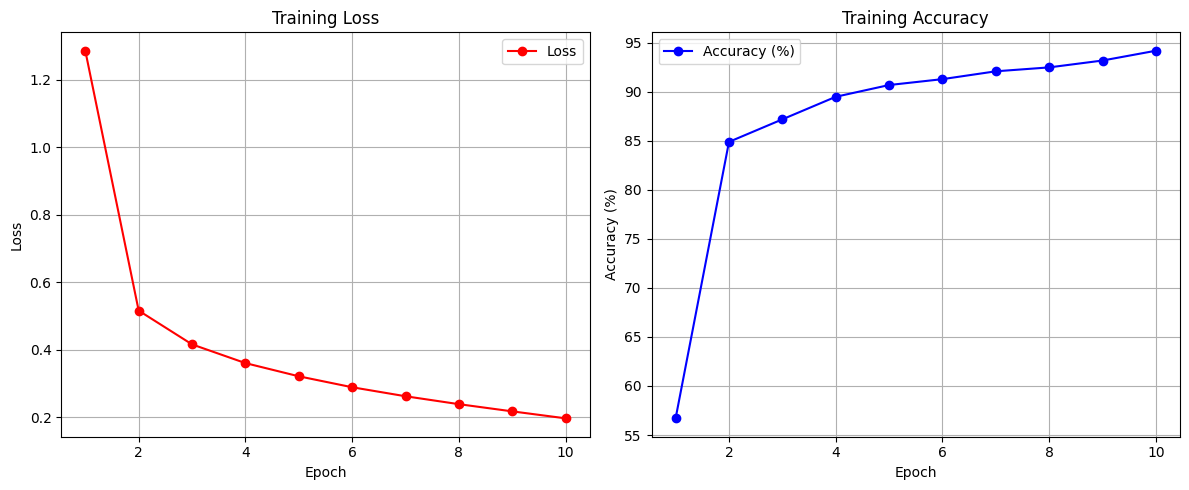

In [130]:
plot_training_history(history)

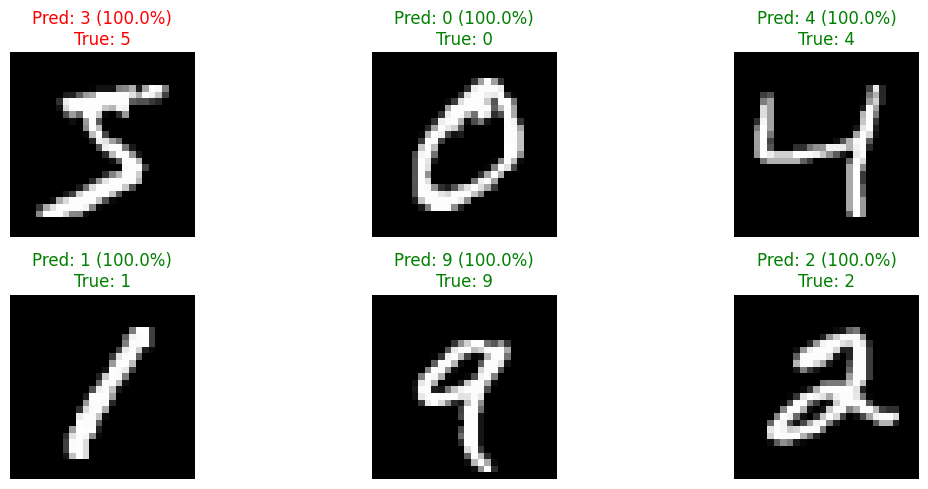

In [135]:
visualize_predictions(cnn, images, labels)